# Penguins Dataset - Logistic Regression

### [Penguins Dataset](https://seaborn.pydata.org/tutorial/introduction.html)

Author: [Kevin Thomas](mailto:ket189@pitt.edu)

## Citation

[1] Allison Horst, https://github.com/allisonhorst/palmerpenguins

## Import Modules

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
from patsy import dmatrices
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Load Dataset

In [2]:
df = pd.read_csv('data/penguins-clean.csv')

In [3]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
4,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


## Logistic Regression

Logistic regression predicts the probability that a sample belongs to a class. We turn the three-class `species` target into a binary target, `is_adelie`, and model the probability that a penguin is an Adelie.

### Create a Binary Target

In [4]:
df['is_adelie'] = (df['species'] == 'Adelie').astype(int)
df['is_adelie'].value_counts()

is_adelie
0    187
1    146
Name: count, dtype: int64

The classes are reasonably balanced, so accuracy is a fair starting metric, but we will still inspect ROC and AUC.

### Visualize Relationship Between the Target and Each Continuous Input

Adelie penguins have shorter bills and flippers. `bill_length_mm` separates the classes most cleanly.

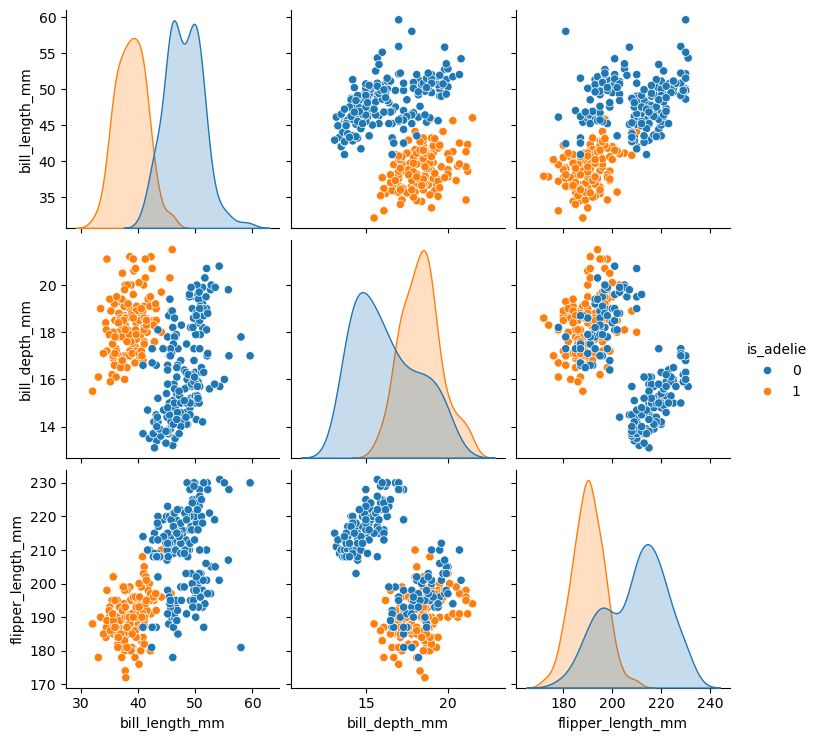

In [5]:
sns.pairplot(
    df,
    vars=['bill_length_mm',
          'bill_depth_mm',
          'flipper_length_mm'],
    hue='is_adelie')
plt.show()

## Fit Logistic Regression Models - Training Data

### Functions

`fit_and_assess_logit` fits a model with the statsmodels formula API and returns one row of metrics. `predict_class` turns probabilities into class labels at a 0.5 threshold.

In [6]:
def fit_and_assess_logit(model, formula, df):
    """
    Fit a logistic regression model and return its metrics.

    Parameters:
        model (str): A descriptive name for the model.
        formula (str): A statsmodels formula string.
        df (pandas.DataFrame): The input data.

    Returns:
        pandas.DataFrame: A single-row DataFrame of metrics.
    """
    a_model = smf.logit(formula=formula, data=df).fit(disp=0)
    preds = predict_class(a_model, df)
    results_dict = {'model_name': model,
                    'model_formula': formula,
                    'num_coefs': len(a_model.params),
                    'pseudo_r2': a_model.prsquared,
                    'aic': a_model.aic,
                    'accuracy': (preds == df['is_adelie']).mean()}
    return pd.DataFrame(results_dict, index=[0])


def predict_class(a_model, df):
    """
    Predict binary class labels from a fitted model.

    Parameters:
        a_model (statsmodels.discrete.discrete_model.BinaryResultsWrapper): Fitted model.
        df (pandas.DataFrame): The input data.

    Returns:
        numpy.ndarray: Predicted class labels.
    """
    probs = a_model.predict(df)
    return (probs >= 0.5).astype(int)

### Formulas

Island is left out of the predictors because every Gentoo penguin in this dataset lives on Biscoe island, which would leak the label.

In [7]:
formula_00 = 'is_adelie ~ 1'
formula_01 = 'is_adelie ~ flipper_length_mm'
formula_02 = 'is_adelie ~ bill_length_mm + bill_depth_mm + flipper_length_mm'
formula_03 = 'is_adelie ~ bill_length_mm + bill_depth_mm + flipper_length_mm + C(sex)'
formula_04 = 'is_adelie ~ bill_length_mm * bill_depth_mm + flipper_length_mm'
formula_05 = 'is_adelie ~ flipper_length_mm * C(sex)'
formula_05

'is_adelie ~ flipper_length_mm * C(sex)'

### Model 00: Intercept-Only (Baseline)

In [8]:
fit_and_assess_logit('Model 00', formula_00, df)

,model_name,model_formula,num_coefs,pseudo_r2,aic,accuracy
0,Model 00,is_adelie ~ 1,1,7.149836e-13,458.575142,0.561562


### Model 01: Flipper Length Only

In [9]:
fit_and_assess_logit('Model 01', formula_01, df)

,model_name,model_formula,num_coefs,pseudo_r2,aic,accuracy
0,Model 01,is_adelie ~ flipper_length_mm,2,0.450399,254.93432,0.822823


### Model 02: All Continuous Predictors

In [10]:
fit_and_assess_logit('Model 02', formula_02, df)

,model_name,model_formula,num_coefs,pseudo_r2,aic,accuracy
0,Model 02,is_adelie ~ bill_length_mm + bill_depth_mm + f...,4,0.9658,23.614828,0.990991


### Model 03: Continuous Predictors + Sex

In [11]:
fit_and_assess_logit('Model 03', formula_03, df)

/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


,model_name,model_formula,num_coefs,pseudo_r2,aic,accuracy
0,Model 03,is_adelie ~ bill_length_mm + bill_depth_mm + f...,5,1.0,10.000157,1.0


### Model 04: Continuous Interaction

In [12]:
fit_and_assess_logit('Model 04', formula_04, df)

,model_name,model_formula,num_coefs,pseudo_r2,aic,accuracy
0,Model 04,is_adelie ~ bill_length_mm * bill_depth_mm + f...,5,0.965802,25.613883,0.990991


### Model 05: Flipper Length Interacting With Sex

In [13]:
fit_and_assess_logit('Model 05', formula_05, df)

,model_name,model_formula,num_coefs,pseudo_r2,aic,accuracy
0,Model 05,is_adelie ~ flipper_length_mm * C(sex),4,0.482506,244.275095,0.840841


### Compare Fitted Models - Training Data

Model 03 and Model 04 reach the highest accuracy with the fewest coefficients. Higher pseudo R-squared and lower AIC both indicate a better fit.

In [14]:
training_results = pd.concat([
    fit_and_assess_logit('Model 00', formula_00, df),
    fit_and_assess_logit('Model 01', formula_01, df),
    fit_and_assess_logit('Model 02', formula_02, df),
    fit_and_assess_logit('Model 03', formula_03, df),
    fit_and_assess_logit('Model 04', formula_04, df),
    fit_and_assess_logit('Model 05', formula_05, df)])
training_results.sort_values('accuracy', ascending=False)

/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


,model_name,model_formula,num_coefs,pseudo_r2,aic,accuracy
0,Model 03,is_adelie ~ bill_length_mm + bill_depth_mm + f...,5,9.999997e-01,10.000157,1.000000
0,Model 02,is_adelie ~ bill_length_mm + bill_depth_mm + f...,4,9.658001e-01,23.614828,0.990991
0,Model 04,is_adelie ~ bill_length_mm * bill_depth_mm + f...,5,9.658022e-01,25.613883,0.990991
0,Model 05,is_adelie ~ flipper_length_mm * C(sex),4,4.825056e-01,244.275095,0.840841
0,Model 01,is_adelie ~ flipper_length_mm,2,4.503986e-01,254.934320,0.822823
0,Model 00,is_adelie ~ 1,1,7.149836e-13,458.575142,0.561562


## Fit Logistic Regression Models w/ Cross-Validation - Test Data

### Functions

In [15]:
def logit_cross_val_score(model, formula, init_model, df, cv):
    """
    Run cross-validated evaluation for a logistic regression formula.

    Parameters:
        model (str): A human-readable model name.
        formula (str): A Patsy-compatible formula string.
        init_model (object): An unfitted scikit-learn estimator.
        df (pandas.DataFrame): The input data.
        cv (int): Number of cross-validation folds.

    Returns:
        pandas.DataFrame: Per-fold accuracy scores.
    """
    y, X = dmatrices(formula, data=df, return_type='dataframe')
    y = np.ravel(y)
    scores = cross_val_score(init_model, X, y, cv=cv, scoring='accuracy')
    return pd.DataFrame({'model_name': model,
                         'fold': range(1, cv + 1),
                         'accuracy': scores})

### Fit w/ Cross-Validation

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_models = [('Model 00', formula_00),
             ('Model 01', formula_01),
             ('Model 02', formula_02),
             ('Model 03', formula_03),
             ('Model 04', formula_04),
             ('Model 05', formula_05)]
cv_results = pd.concat([
    logit_cross_val_score(name, formula, LogisticRegression(max_iter=5000), df, 5)
    for name, formula in cv_models])
cv_results.head()

,model_name,fold,accuracy
0,Model 00,1,0.552239
1,Model 00,2,0.567164
2,Model 00,3,0.567164
3,Model 00,4,0.560606
4,Model 00,5,0.560606


### Compare Fitted Models - Test Data

The cross-validated accuracy is the honest estimate. Model 03 is a strong choice: high accuracy with fewer coefficients than Model 04.

In [17]:
cv_summary = cv_results.groupby('model_name')['accuracy'].agg(['mean', 'std', 'count'])
cv_summary = cv_summary.sort_values('mean', ascending=False)
cv_summary

,mean,std,count
model_name,,,
Model 03,0.985029,0.010554,5
Model 02,0.979059,0.016998,5
Model 04,0.979059,0.013325,5
Model 05,0.805246,0.165472,5
Model 01,0.787291,0.148884,5
Model 00,0.561556,0.006155,5


### Visualize Average Accuracy w/ 1 Standard Error Interval

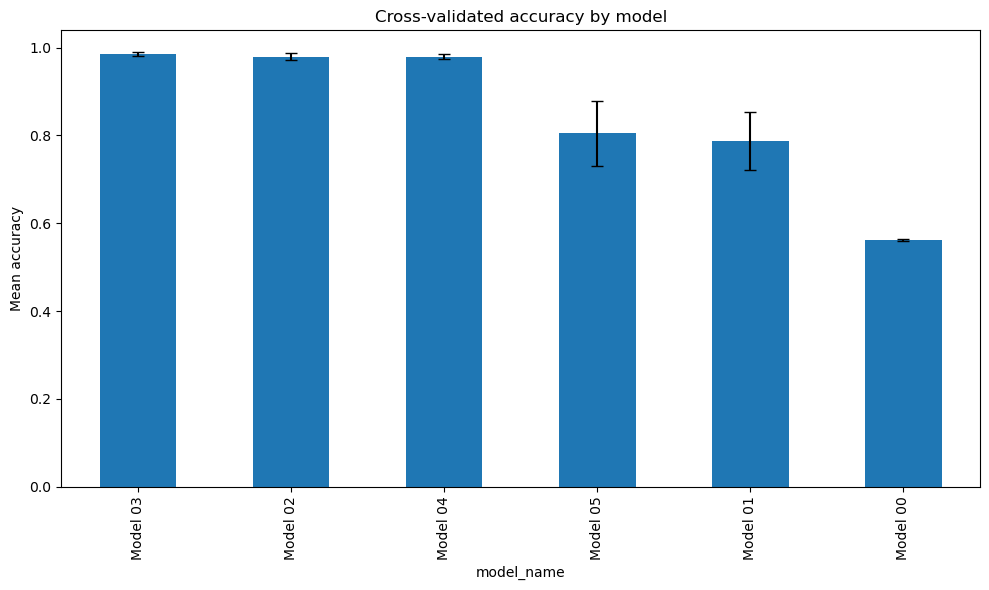

In [18]:
ax = cv_summary['mean'].plot(
    kind='bar',
    yerr=cv_summary['std'] / np.sqrt(cv_summary['count']),
    capsize=4,
    figsize=(10, 6))
ax.set_ylabel('Mean accuracy')
ax.set_title('Cross-validated accuracy by model')
plt.tight_layout()
plt.show()

### Visualize ROC Curves

A model with a high AUC ranks Adelie above non-Adelie across all thresholds. Model 03 is close to a perfect ranker.

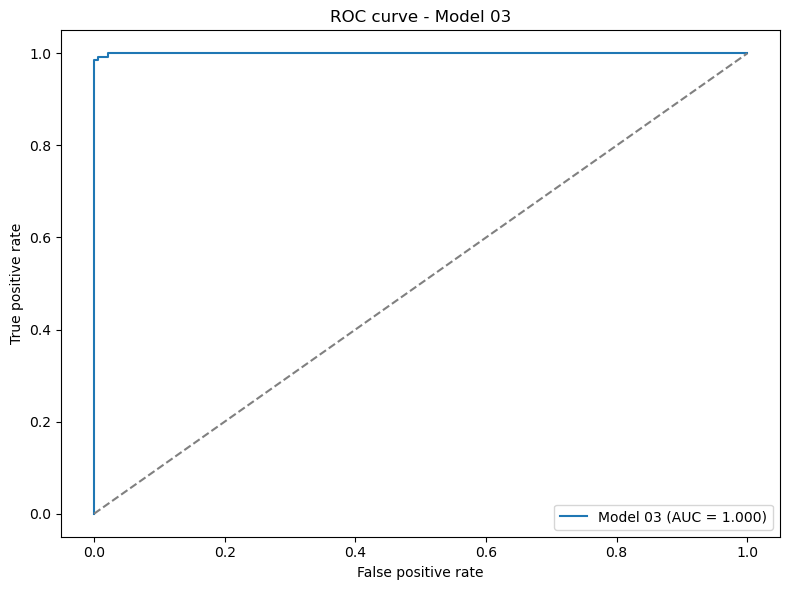

In [19]:
y, X = dmatrices(formula_03, data=df, return_type='dataframe')
y = np.ravel(y)
best_model = LogisticRegression(max_iter=5000).fit(X, y)
probs = best_model.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(y, probs)
auc_score = roc_auc_score(y, probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Model 03 (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('ROC curve - Model 03')
plt.legend()
plt.tight_layout()
plt.show()

### Confusion Matrix and Classification Report

In [20]:
preds = (probs >= 0.5).astype(int)
print(confusion_matrix(y, preds))
print(classification_report(y, preds))

[[186   1]
 [  1 145]]
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99       187
         1.0       0.99      0.99      0.99       146

    accuracy                           0.99       333
   macro avg       0.99      0.99      0.99       333
weighted avg       0.99      0.99      0.99       333



## Save Best Model - Model 03 w/ Highest Cross-Validated Accuracy

### Save Model

In [21]:
final_model = smf.logit(formula=formula_03, data=df).fit(disp=0)
with open('models/logit_model.pkl', 'wb') as handle:
    pickle.dump(final_model, handle)
print(final_model.summary())

                           Logit Regression Results                           
Dep. Variable:              is_adelie   No. Observations:                  333
Model:                          Logit   Df Residuals:                      328
Method:                           MLE   Df Model:                            4
Date:                Thu, 24 Sep 2026   Pseudo R-squ.:                   1.000
Time:                        10:18:04   Log-Likelihood:            -7.8366e-05
converged:                      False   LL-Null:                       -228.29
Covariance Type:            nonrobust   LLR p-value:                 1.646e-97
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1059.3043   1.94e+08   5.46e-06      1.000    -3.8e+08     3.8e+08
C(sex)[T.Male]      117.0684   1.71e+07   6.85e-06      1.000   -3.35e+07    3.35e+07
bill_length_mm      -67.

/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/envs/prod/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


### Load Model

In [22]:
with open('models/logit_model.pkl', 'rb') as handle:
    loaded_model = pickle.load(handle)
loaded_model.params

Intercept            1059.304311
C(sex)[T.Male]        117.068432
bill_length_mm        -67.987582
bill_depth_mm         103.687470
flipper_length_mm      -0.053247
dtype: float64

### Inference on New Data

Feed the loaded model a new penguin and read the probability that it is an Adelie.

In [23]:
new_penguin = pd.DataFrame({
    'bill_length_mm': [39.0],
    'bill_depth_mm': [18.5],
    'flipper_length_mm': [190.0],
    'sex': ['Female']})
probability = loaded_model.predict(new_penguin).iloc[0]
print(f'Probability of Adelie: {probability:.4f}')
print('Predicted class:', 'Adelie' if probability >= 0.5 else 'Not Adelie')

Probability of Adelie: 1.0000
Predicted class: Adelie
